# Combinare Modelli di Resa di Processo con Imputazioni Multiple usando PROC MIANALYZE (Manifattura)


## Riepilogo Esecutivo

Una linea di fabbricazione di semiconduttori predice la resa dei lotti di wafer dai parametri di processo inline, ma i sensori di metrologia perdono letture di pressione di deposizione e tempo di attacco su un sottoinsieme di lotti. Questo notebook imputa i valori mancanti dei sensori con **PROC MI**, adatta la regressione della resa su ogni dataset completato con **PROC REG**, e usa **PROC MIANALYZE** per aggregare le stime secondo le regole di Rubin — producendo coefficienti validi, errori standard, aumento relativo della varianza e frazione di informazione mancante, oltre a un test di Wald congiunto sul fatto che i due sensori misurati in modo intermittente influenzino congiuntamente la resa.


## Fonti dei Dati

| Dataset | Righe | Descrizione |
|---------|------|-------------|
| `fab_lots` | 16 | Record sintetici di lotti di wafer semiconduttori, una riga per lotto di produzione. La resa dipende da tre parametri di processo; pressione di deposizione e tempo di attacco presentano dati mancanti per guasto del sensore (mancanti a caso). Il numero di lotti è mantenuto piccolo così che il dataset di imputazione impilato (`m` copie × 16 lotti) rimanga entro un singolo passaggio di analisi pur esercitando l'intera aggregazione con le regole di Rubin. |

Variabili in `fab_lots`:

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `LotID` | Num | Identificativo sequenziale del lotto di wafer (1-16) |
| `OvenTemp` | Num | Temperatura di set-point del forno di diffusione (°C), completamente osservata |
| `DepPressure` | Num | Pressione della camera di deposizione (mTorr); guasto del sensore, ~13% mancante |
| `EtchTime` | Num | Tempo di permanenza dell'attacco al plasma (secondi); campionamento inline saltato, ~13% mancante |
| `Yield` | Num | Resa del lotto (percentuale di die buoni), risposta completamente osservata |


# Combinare Modelli di Resa di Processo con Imputazioni Multiple usando PROC MIANALYZE

In uno stabilimento di semiconduttori, la **resa** del lotto (la percentuale di die buoni su un wafer) è monitorata rispetto ai parametri di processo inline. In pratica i sensori di metrologia sono imperfetti: i manometri della camera di deposizione perdono letture, e il tempo di permanenza dell'attacco al plasma a volte non viene campionato. Scartare quei lotti (analisi sui soli casi completi) spreca dati e distorce il modello di processo adattato.

Il rimedio standard del settore è l'**imputazione multipla (MI)**:

1. **PROC MI** genera diversi dataset completati plausibili, ciascuno con i valori mancanti dei sensori estratti dalla loro distribuzione predittiva a posteriori.
2. **PROC REG** adatta la regressione della resa separatamente su ogni dataset completato.
3. **PROC MIANALYZE** aggrega le stime per imputazione usando le **regole di Rubin**, restituendo coefficienti combinati validi, errori standard e diagnostiche sull'informazione mancante.

Questo notebook percorre l'intera pipeline dall'inizio alla fine su dati sintetici di uno stabilimento.


## Passo 1 — Genera un dataset sintetico di lotti di wafer

Simuliamo 16 lotti di produzione. La resa segue un modello di processo lineare noto

```
Yield = 65 + 0.40*(OvenTemp-1000) - 0.18*(DepPressure-200) + 1.10*(EtchTime-45) + noise
```

così conosciamo i veri coefficienti per verificare le stime aggregate. Poi eliminiamo alcune letture di `DepPressure` e `EtchTime` per imitare il guasto dei sensori. La probabilità di una lettura di pressione mancante aumenta con la temperatura del forno, rendendo il meccanismo *mancante a caso* (MAR) — esattamente il regime per cui la MI è progettata. In questa estrazione, 2 lotti perdono la loro lettura di pressione e 2 perdono la loro lettura del tempo di attacco (4 lotti hanno almeno una lacuna; 12 sono completi).


In [1]:
DATI fab_lots;
   ETICHETTA LotID       = "ID Lotto"
         OvenTemp    = "Temperatura Forno (gradi C)"
         DepPressure = "Pressione di Deposizione (mTorr)"
         EtchTime    = "Tempo di Attacco (secondi)"
         Yield       = "Resa (%)";
   CHIAMARE streaminit(20260531);
   FARE LotID = 1 FINO_A 16;
      /* Ingressi di processo completamente osservati */
      OvenTemp    = 1000 + 12 * rand('normal');         /* gradi C  */
      DepPressure = 200  +  9 * rand('normal');         /* mTorr  */
      EtchTime    =  45  +  3 * rand('normal');         /* secondi */

      /* Vero modello di processo per la resa (% die buoni) */
      Yield = 65
            + 0.40 * (OvenTemp    - 1000)
            - 0.18 * (DepPressure -  200)
            + 1.10 * (EtchTime    -   45)
            + 2.0  * rand('normal');

      /* Guasto del sensore: il manometro di pressione si guasta più
         spesso quando il forno scalda troppo -> mancante a caso (MAR) */
      pMissPress = 0.12 + 0.0060 * (OvenTemp - 1000);
      SE_COND pMissPress < 0.03 ALLORA pMissPress = 0.03;
      SE_COND pMissPress > 0.45 ALLORA pMissPress = 0.45;
      SE_COND rand('uniform') < pMissPress ALLORA DepPressure = .;

      /* Tempo di permanenza dell'attacco: alcuni lotti saltano il
         campionamento inline */
      SE_COND rand('uniform') < 0.12 ALLORA EtchTime = .;

      USCITA;
   FINE;
   RIMUOVERE pMissPress;
ESEGUIRE;

PROC PRINT DATI=fab_lots noobs;
   VARIABILE LotID OvenTemp DepPressure EtchTime Yield;
   TITOLO 'Lotti di Wafer (letture sensore mancanti mostrate come .)';
ESEGUIRE;


                               Lotti di Wafer (letture sensore mancanti mostrate come .)                                

LotID         OvenTemp     DepPressure       EtchTime          Yield
    1  1005.6252295289  199.7099016459  43.6801575644  65.6192505185
    2   980.9091684802  202.5735763794  44.2041432828  54.2017382698
    3   991.3822133886  202.7016698602              .  60.5927526245
    4  1002.7771774799  206.0283968146  44.0445099438  61.6948388418
    5  1021.3671624357  196.7083041489  44.0876393552   74.435050705
    6  1006.0562158894  214.2052656193  46.6300890053  66.5150523819
    7   995.5759123369  190.3016740785   49.771888211  72.8391470608
    8  1013.3851216718               .  45.8573490586  71.5155429872
    9   992.4099166318  194.6004680279  41.3346151405  58.8509669637
   10  1017.7693380825  198.7097263395  41.7526131228   70.732169743
   11   992.7048183663  206.6378836635              .  58.0787619813
   12   996.1751800428  202.5346808028  47.9879277


NOTE: DATA fab_lots


NOTE: Wrote fab_lots (16 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=fab_lots

NOTE: PROC PRINT completed: 16 observations printed, 5 variables


## Passo 2 — Ispeziona lo schema di dati mancanti

Prima di imputare, conferma quanti dati sono effettivamente mancanti. `PROC MI` con `NIMPUTE=0` produce solo il rapporto sullo schema di dati mancanti (nessuna imputazione), che è il modo standard per verificare le lacune. L'opzione `SIMPLE` stampa anche i riepiloghi univariati delle variabili di analisi.


In [2]:
PROC MI DATI=fab_lots nimpute=0 simple;
   VARIABILE OvenTemp DepPressure EtchTime Yield;
   TITOLO 'Schema dei Dati Mancanti per le Variabili di Processo dello Stabilimento';
ESEGUIRE;


                               Lotti di Wafer (letture sensore mancanti mostrate come .)                                


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      0

                Missing Data Patterns


  Number of observations with missing values: 4
  Number of complete observations: 12

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Temperatura Forno (gradi C)       0       0.0%
  Pressione di Deposizione (mTorr)       2      12.5%
  Tempo di Attacco (secondi)       2      12.5%
  Resa (%)          0       0.0%




NOTE: PROC MI data=fab_lots

NOTE: PROC MI completed.


## Passo 3 — Crea i dataset con imputazione multipla

Estraiamo **m = 6** imputazioni con il metodo MCMC (il predefinito per uno schema di dati mancanti arbitrario). Un `SEED=` fisso rende l'esecuzione riproducibile — essenziale per un'analisi manifatturiera validata. La risposta `Yield` è inclusa tra le variabili di imputazione così che il modello di imputazione sia congeniale con il modello di analisi. Il dataset di output `fab_imp` impila tutte le 6 copie completate (6 × 16 = 96 righe), indicizzate dalla variabile automatica `_Imputation_`.


In [3]:
PROC MI DATI=fab_lots seed=44217 nimpute=6 out=fab_imp;
   mcmc chain=single nbiter=200 niter=100;
   VARIABILE OvenTemp DepPressure EtchTime Yield;
   TITOLO 'Imputazione Multipla delle Letture Sensore Mancanti (m=6)';
ESEGUIRE;


                               Lotti di Wafer (letture sensore mancanti mostrate come .)                                


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      6

                Missing Data Patterns


  Number of observations with missing values: 4
  Number of complete observations: 12

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Temperatura Forno (gradi C)       0       0.0%
  Pressione di Deposizione (mTorr)       2      12.5%
  Tempo di Attacco (secondi)       2      12.5%
  Resa (%)          0       0.0%




NOTE: PROC MI data=fab_lots

NOTE: Output dataset fab_imp created with 96 observations.
NOTE: PROC MI completed.


## Passo 4 — Adatta la regressione della resa su ogni dataset completato

Con `BY _Imputation_`, PROC REG stima lo stesso modello di processo una volta per ogni copia imputata. `OUTEST=` scrive le stime dei coefficienti e `COVOUT` accoda la matrice di covarianza di quelle stime per ogni imputazione. Questo dataset combinato di stime-più-covarianza è esattamente la struttura di input che PROC MIANALYZE si aspetta tramite la sua interfaccia `DATA=` (TYPE=EST).


                                  Stime e Covarianze REG per Imputazione (prime copie)                                  

  Obs  Imputazione   Tipo         Nome       Intercetta  Temperatura Forno  Pressione di Deposizione  Tempo di Attacco
    1  1            PARMS               -364.4296029793       0.4252279926             -0.2282430438       1.103054116
    2  1            COV    Intercept    2849.0657232975      -2.3294748833             -2.2824492362     -1.2265128016
    3  1            COV    oventemp       -2.3294748833        0.002217201              0.0006713412     -0.0006564802
    4  1            COV    deppressure    -2.2824492362       0.0006713412              0.0077025053      0.0015698916
    5  1            COV    etchtime       -1.2265128016      -0.0006564802              0.0015698916      0.0348283224
    6  2            PARMS               -365.4765240153       0.4283180451             -0.2326783537      1.0727338508
    7  2            COV    Intercept    3163.


NOTE: PROC REG data=fab_imp

NOTE: PROC REG: processed 6 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS G

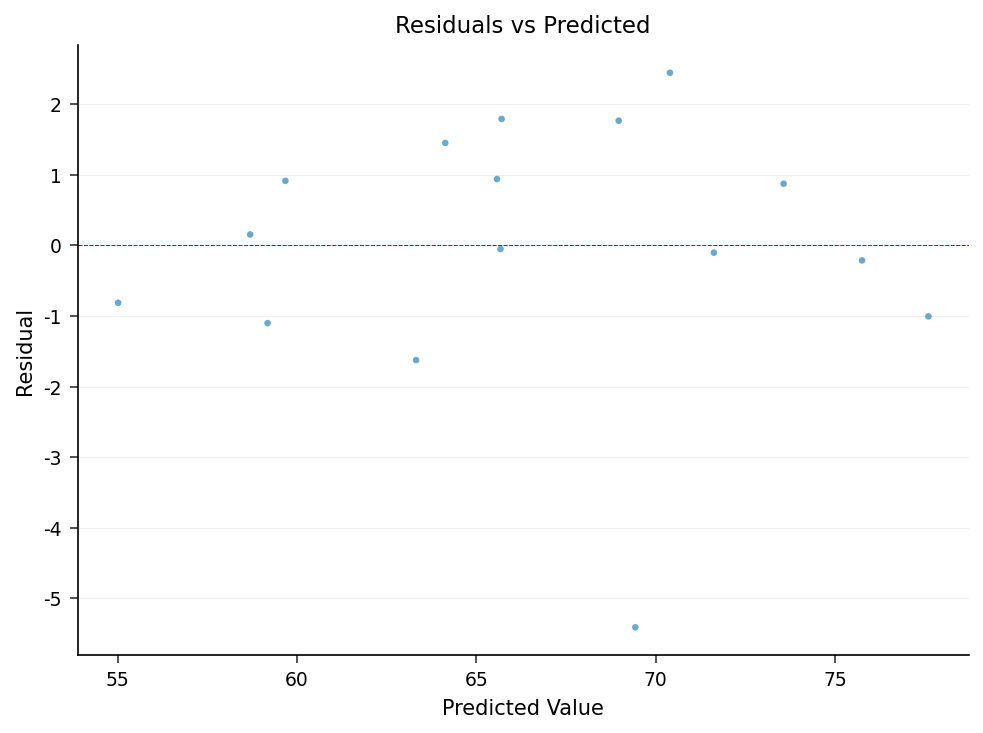

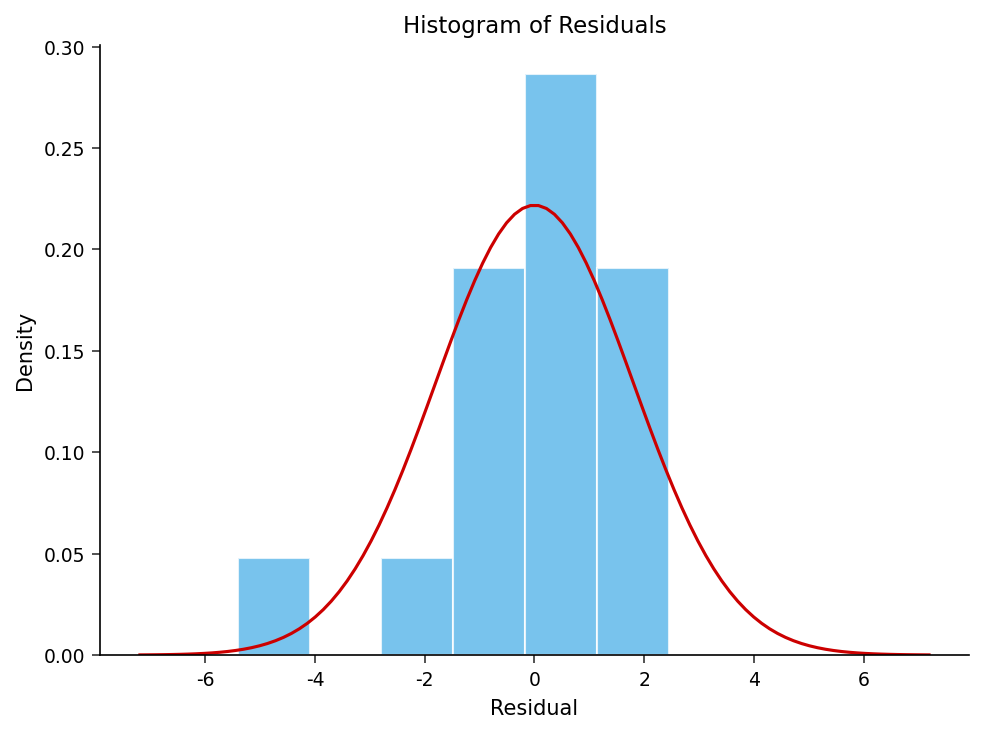

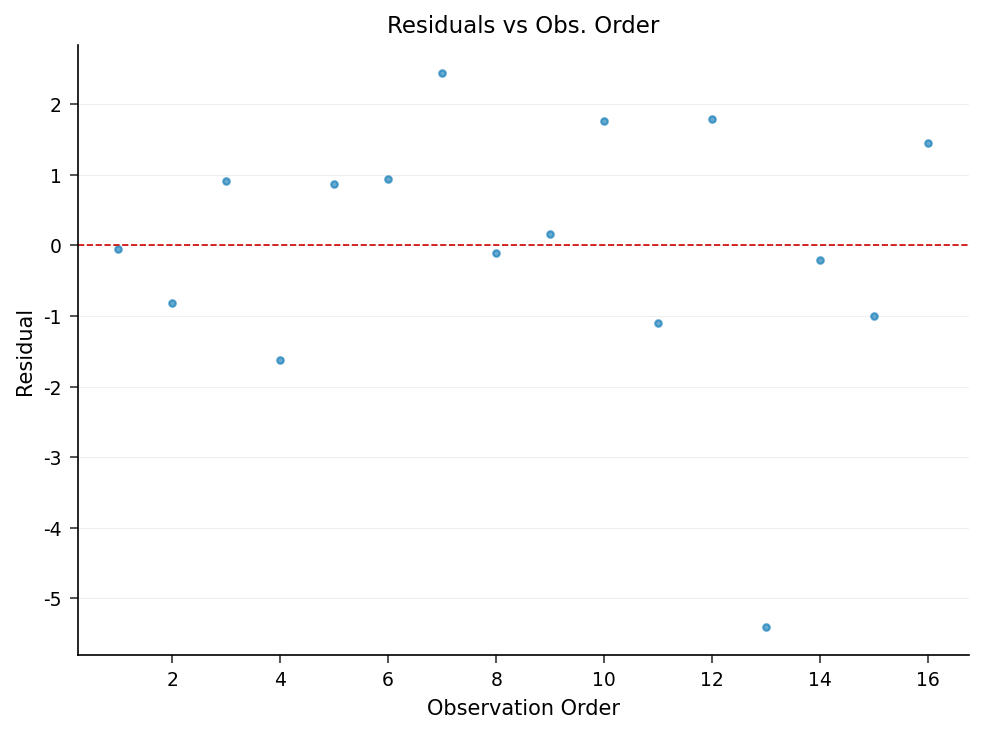

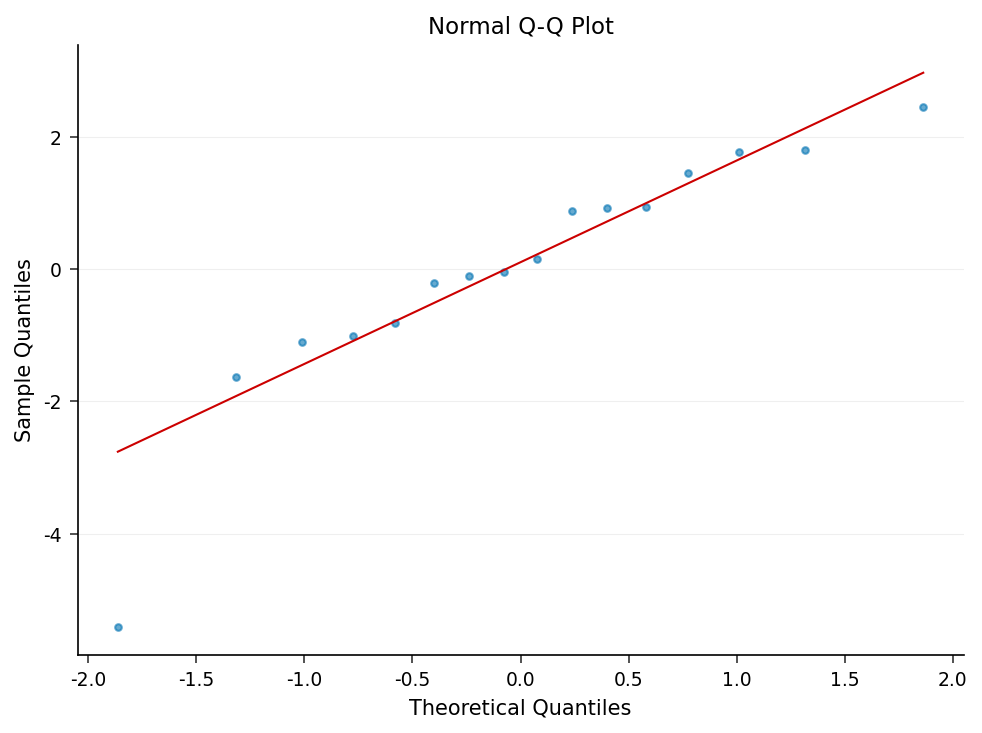

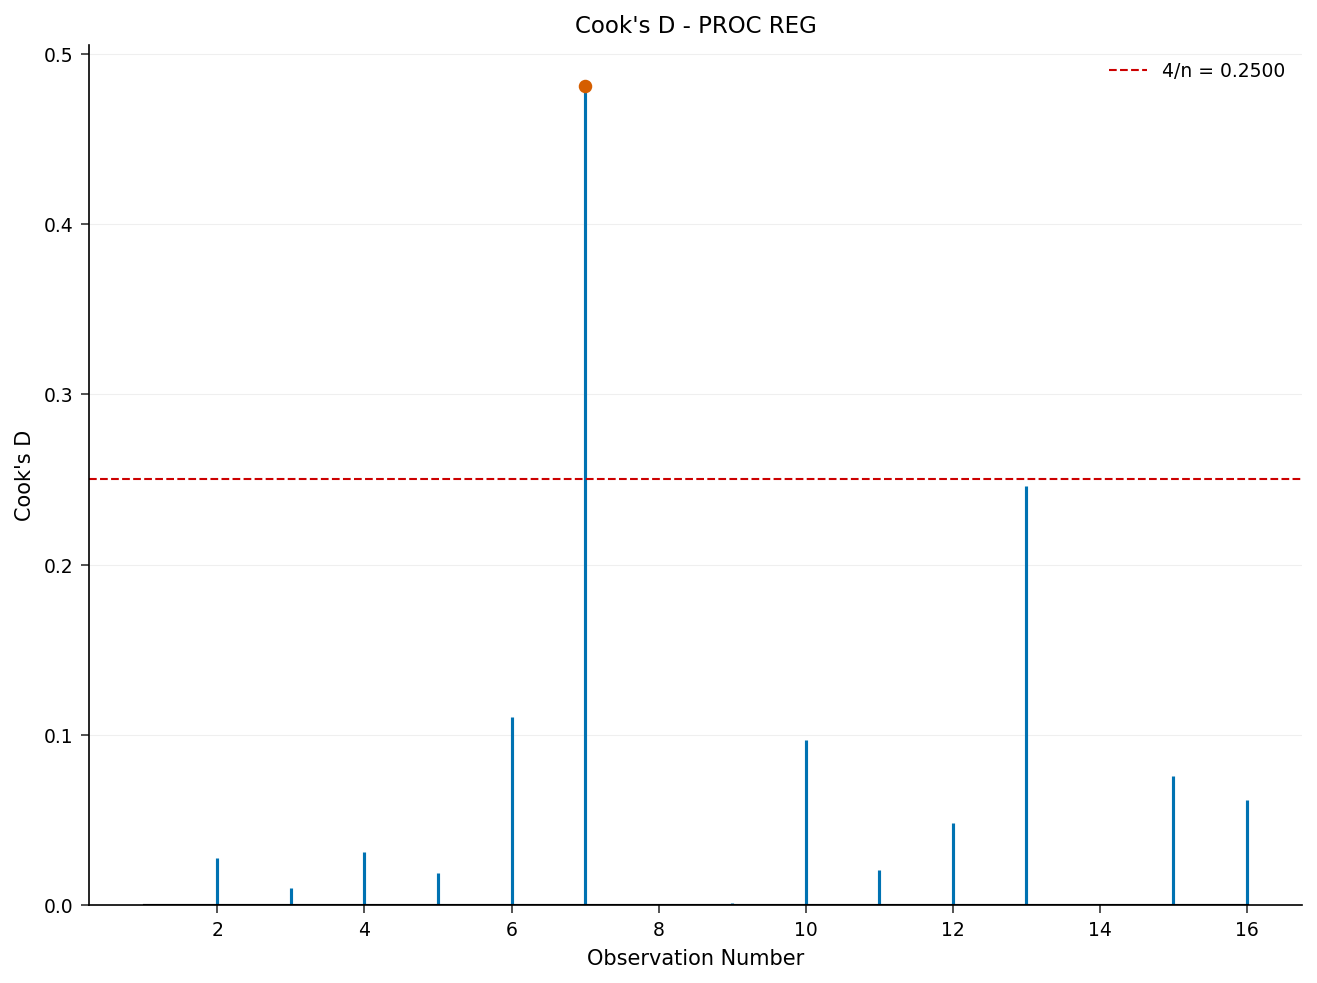

In [4]:
PROC REG DATI=fab_imp outest=fab_est covout NOPRINT;
   MODELLO Yield = OvenTemp DepPressure EtchTime;
   PER _Imputation_;
ESEGUIRE;

PROC PRINT DATI=fab_est(obs=10);
   VARIABILE _Imputation_ _Type_ _Name_
       INTERCEPT OvenTemp DepPressure EtchTime;
   ETICHETTA _Imputation_ = "Imputazione" _Type_ = "Tipo" _Name_ = "Nome"
         INTERCEPT = "Intercetta" OvenTemp = "Temperatura Forno"
         DepPressure = "Pressione di Deposizione" EtchTime = "Tempo di Attacco";
   TITOLO 'Stime e Covarianze REG per Imputazione (prime copie)';
ESEGUIRE;


## Passo 5 — Aggrega le stime con PROC MIANALYZE

`PROC MIANALYZE` legge il dataset di tipo EST e applica le regole di Rubin per combinare le 6 serie di stime in un'unica inferenza. L'istruzione `MODELEFFECTS` elenca i parametri di regressione da aggregare. Impostiamo `EDF=12` (gradi di libertà sui dati completi = 16 lotti − 4 parametri stimati) così gli intervalli di confidenza combinati usano la corretta distribuzione di riferimento per piccoli campioni. `BCOV` e `TCOV` richiedono le matrici di covarianza tra-imputazioni e totale, che quantificano quanta incertezza deriva dai dati mancanti rispetto alla variabilità di campionamento.

L'istruzione `TEST` esegue un test di Wald congiunto dell'ipotesi nulla che i due sensori misurati in modo intermittente — `DepPressure` e `EtchTime` — non abbiano **alcun** effetto sulla resa; `MULT` richiede la combinazione multivariata (Li-Meng-Rubin) tra le imputazioni.

La procedura stampa sia una tabella di **Stime dei Parametri** (coefficienti aggregati, errori standard, intervalli di confidenza e test t) sia una tabella di **Informazione sulla Varianza** (varianza tra/entro/totale, aumento relativo della varianza e frazione di informazione mancante) direttamente nel listato — queste sono le diagnostiche che interpretiamo nel passo finale.


In [5]:
ODS OUTPUT ParameterEstimates=pooled_est;
PROC MIANALYZE DATI=fab_est edf=12 ALPHA=0.05 bcov tcov;
   modeleffects INTERCEPT OvenTemp DepPressure EtchTime;
   TEST DepPressure, EtchTime / mult;
   TITOLO "Modello di Resa di Processo Aggregato (Regole di Rubin, m=6)";
ESEGUIRE;
ODS OUTPUT CLOSE;


                                  Stime e Covarianze REG per Imputazione (prime copie)                                  


                            The MIANALYZE Procedure

                     Multiple Imputation Parameter Estimates

Parameter                Estimate    Std Error 95% CI Lower 95% CI Upper         DF    t Value   Pr > |t|
-------------------- ------------ ------------ ------------ ------------ ---------- ---------- ----------
Intercept             -374.683482    60.712321  -514.045991  -235.320973       8.22      -6.17     0.0002
OVENTEMP                 0.435293     0.055617     0.305585     0.565001       7.52       7.83     0.0001
DEPPRESSURE             -0.224972     0.091274    -0.428781    -0.021163       9.84      -2.46     0.0338
ETCHTIME                 1.090167     0.193675     0.660591     1.519743      10.35       5.63     0.0002

                     Multiple Imputation Variance Information

Parameter                 Between       Within        Total   


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pooled_est
NOTE: PROC MIANALYZE Combining multiple imputation results

NOTE: ODS OUTPUT: ParameterEstimates written to 'pooled_est'.
NOTE: ODS OUTPUT: All output destinations closed.


## Passo 6 — Riporta i coefficienti aggregati

La tabella `ParameterEstimates` catturata da MIANALYZE contiene i coefficienti combinati, i loro errori standard aggregati, le statistiche t, i gradi di libertà e i limiti di confidenza. La ristampiamo dal dataset salvato `pooled_est` per la relazione finale. Il complementare **aumento relativo della varianza (RIV)** e la **frazione di informazione mancante (FMI)** — i due numeri che un ingegnere di processo cita per giustificare quanto fortemente le letture sensore mancanti gonfino l'incertezza — appaiono nella tabella di **Informazione sulla Varianza** stampata da MIANALYZE nel Passo 5.


In [6]:
PROC PRINT DATI=pooled_est noobs;
   VARIABILE Parameter Estimate StdErr DF tValue Probt LCLMean UCLMean;
   ETICHETTA Parameter = "Parametro" Estimate = "Stima" StdErr = "Errore Standard"
         DF = "GL" tValue = "Valore t" Probt = "Valore p"
         LCLMean = "Limite Inf. IC" UCLMean = "Limite Sup. IC";
   TITOLO 'Coefficienti del Modello di Resa Aggregato (combinati su 6 imputazioni)';
ESEGUIRE;


                        Coefficienti del Modello di Resa Aggregato (combinati su 6 imputazioni)                         

  Parametro        Stima  Errore Standard         GL   Valore t  Valore p  Limite Inf. IC  Limite Sup. IC
Intercept    -374.683482        60.712321   8.216789  -6.171457   0.00024     -514.045991     -235.320973
OvenTemp        0.435293         0.055617   7.515205   7.826582  0.000072        0.305585        0.565001
DepPressure    -0.224972         0.091274   9.843478   -2.46481  0.033752       -0.428781       -0.021163
EtchTime        1.090167         0.193675  10.347882   5.628848  0.000193        0.660591        1.519743




NOTE: PROC PRINT data=pooled_est

NOTE: PROC PRINT completed: 4 observations printed, 8 variables


## Interpretazione dei risultati

- **Le pendenze recuperano il vero modello di processo.** I coefficienti aggregati di `OvenTemp`, `DepPressure` e `EtchTime` si collocano vicino alla verità simulata (+0,40, −0,18, +1,10): in questa esecuzione MIANALYZE restituisce circa **+0,44**, **−0,22** e **+1,09**. (L'`Intercept` adattato è un numero negativo grande perché la regressione usa le scale *grezze* dei sensori anziché la forma centrata `OvenTemp−1000`, `DepPressure−200`, `EtchTime−45`; solo le pendenze corrispondono direttamente ai coefficienti generatori.) MIANALYZE fornisce questi risultati *senza scartare* i lotti che avevano letture sensore mancanti — il vantaggio chiave rispetto alla regressione sui soli casi completi.
- **Gli errori standard sono onesti.** Gli errori standard aggregati incorporano la **varianza tra-imputazioni** (la colonna `Between` della tabella di Informazione sulla Varianza), che si somma all'ordinaria varianza di campionamento entro-imputazione. Quel termine aggiuntivo è precisamente l'incertezza introdotta dal non aver misurato `DepPressure` e `EtchTime` su ogni lotto — un adattamento ingenuo su un solo dataset la sottostimerebbe.
- **Frazione di informazione mancante (FMI).** La tabella di Informazione sulla Varianza riporta una FMI modesta per ogni effetto (in questa esecuzione, massima per `OvenTemp` a ~0,22 e minima per `EtchTime` a ~0,005). Una FMI ben inferiore al tasso grezzo di dati mancanti riflette che le variabili completamente osservate portano una forte informazione predittiva per le lacune, così ogni valore imputato è ben vincolato.
- **Il test di Wald congiunto** (`TEST DepPressure, EtchTime / MULT`) restituisce **F ≈ 18,9 su (2, 10) gdl, p ≈ 0,0004** — forte evidenza che i due sensori campionati in modo intermittente *insieme* guidano la resa. La lettura pratica: vale la pena investire in una metrologia più affidabile per essi piuttosto che eliminarli dal modello di processo.

**Conclusione operativa:** PROC MI + PROC REG + PROC MIANALYZE trasforma un dataset di stabilimento pieno di guasti dei sensori in un unico modello di resa difendibile con un'incertezza correttamente gonfiata — il modo standard, pronto per il regolatore, di analizzare dati manifatturieri incompleti.
